# LLM Text Classifier — Full Pipeline
**Goal:** Given a text sample, predict which LLM generated it.

**Approach:** Fine-tune a pretrained transformer (DistilBERT) + stylometric features → multi-class softmax classifier.

> Run each cell top-to-bottom. GPU recommended (Google Colab / local CUDA). CPU also works — just slower.

## Step 1 — Install dependencies

Run this once. If you're on **Google Colab**, these are mostly pre-installed.

In [17]:
# Run this cell first — installs all required packages
#!pip install -q transformers datasets scikit-learn pandas numpy matplotlib seaborn shap textstat tqdm accelerate
import sys
import subprocess
import importlib

def install_if_missing(packages):
    """
    Checks if packages are installed. If not, installs them via pip.
    'packages' should be a dictionary of {import_name: pip_name}.
    """
    for import_name, pip_name in packages.items():
        try:
            # Try to import the library
            importlib.import_module(import_name)
            print(f"✅ {import_name} is already installed.")
        except ImportError:
            # If it fails, install it using the current Python environment's pip
            print(f"⏳ {import_name} not found. Installing {pip_name}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
            print(f"✅ Successfully installed {pip_name}.")

# Dictionary mapping the library name in Python to its actual pip install name.
# (e.g., you import 'sklearn', but you pip install 'scikit-learn')
required_packages = {
    'os': 'os',
    'warnings': 'warnings',
    'random': 'random',
    'collections': 'collections',
    're': 're',
    'torch': 'torch',
    'accelerate': 'accelerate',
    'shap': 'shap',
    'datasets': 'datasets',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'torch': 'torch',
    'transformers': 'transformers',
    'sklearn': 'scikit-learn',  # Remember the name difference here
    'textstat': 'textstat',
    'tqdm': 'tqdm'
}

# Run the installation check
print("--- Checking Environment Setup ---")
install_if_missing(required_packages)
print("--- Setup Complete. Ready to Import! ---")

--- Checking Environment Setup ---
✅ os is already installed.
✅ warnings is already installed.
✅ random is already installed.
✅ collections is already installed.
✅ re is already installed.
✅ torch is already installed.
✅ accelerate is already installed.
✅ shap is already installed.
✅ datasets is already installed.
✅ numpy is already installed.
✅ pandas is already installed.
✅ matplotlib is already installed.
✅ seaborn is already installed.
✅ transformers is already installed.
✅ sklearn is already installed.
✅ textstat is already installed.
✅ tqdm is already installed.
--- Setup Complete. Ready to Import! ---


## Step 2 — Imports

All libraries used in this notebook:
- `transformers` — pretrained BERT/DistilBERT models and tokenizers  
- `torch` — deep learning framework  
- `sklearn` — metrics, label encoding, train/test split  
- `textstat` — readability and stylometric scores  
- `shap` — model explainability  
- `seaborn / matplotlib` — visualizations

In [18]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# ── Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ── HuggingFace
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

# ── Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ── Stylometric helpers
import textstat
import re
from collections import Counter
from tqdm.auto import tqdm

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Step 3 — Configuration

All hyperparameters and paths in one place. Change these to tune your model.

In [19]:
# Parent variables
MODEL_NAMES = ["distilbert-base-uncased", "roberta-base", "microsoft/deberta-v3-base"]
MAX_LENS = [256, 512, 128]
BATCH_SIZES = [16, 32]
LRS = [2e-5, 3e-5, 1e-5]

In [20]:
# ── Change DATA_PATH to your actual CSV file path
#DATA_PATH   = "/home/ayush/Documents/AI_project/cook_here/Dataset_cleaned/split_downsample/Dataset_small"          # CSV with columns: text, generated_by
DATA_PATH   = '/kaggle/input/datasets/ayusheinsteinyadav/project'
TEXT_COL    = "text"
LABEL_COL   = "generated_by"

# ── Model
#MODEL_NAME  = "distilbert-base-uncased"   # lightweight, fast; swap with
#MODEL_NAME = "roberta-base"               # usually +5–10% on classification tasks
#MODEL_NAME = "microsoft/deberta-v3-base"  # state-of-the-art for text classification
MODEL_NAME = MODEL_NAMES[1]

#MAX_LEN     = 256      # max token length per sample (increase for longer texts)
# MAX_LEN = 512   # try this first
# MAX_LEN = 128  # only if memory is the constraint
MAX_LEN = MAX_LENS[0]

#BATCH_SIZE  = 16       # reduce to 8 if you hit OOM
#BATCH_SIZE = 32   # larger batches stabilize gradients (if memory allows)
BATCH_SIZE = BATCH_SIZES[0]

EPOCHS      = 1     # more epochs with early stopping

#LR          = 2e-5     # AdamW learning rate
#LR = 3e-5   # try slightly higher
#LR = 1e-5   # try lower if training loss is unstable
LR = LRS[0]

DROPOUT     = 0.3

# ── Paths
CHECKPOINT  = "best_model.pt"     # saved when val loss improves

## Step 4 — Load & inspect data

Your CSV must have at minimum two columns:
- `text` — the generated text
- `generated_by` — the LLM name (e.g. `"gpt-4"`, `"claude"`, `"gemini"`)

In [21]:
train_df = pd.read_parquet(f'{DATA_PATH}/train.parquet')
test_df = pd.read_parquet(f'{DATA_PATH}/test.parquet')
val_df = pd.read_parquet(f'{DATA_PATH}/val.parquet')

train_df['split_source'] = 'train'
val_df['split_source'] = 'val'
test_df['split_source'] = 'test'

combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

In [22]:
df = combined_df.copy()
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (9958, 3)
Columns: ['text', 'generated_by', 'split_source']


,text,generated_by,split_source
0,"\n\nA family Christmas,\n\nIs a time for love ...",gpt3,train
1,Whеn rеnоwnеd dеtесtіvе Εmіlу Dunсаn іs саllеd...,llama-chat,train
2,"""Unbreakable"" is a movie that is not only a gr...",mistral,train


Rows after dropping nulls: 9958

Class distribution:
generated_by
cohere          832
llama-chat      831
gpt2            831
mistral-chat    831
mpt             831
chatgpt         830
mpt-chat        829
gpt3            829
cohere-chat     829
gpt4            829
mistral         828
human           828
Name: count, dtype: int64


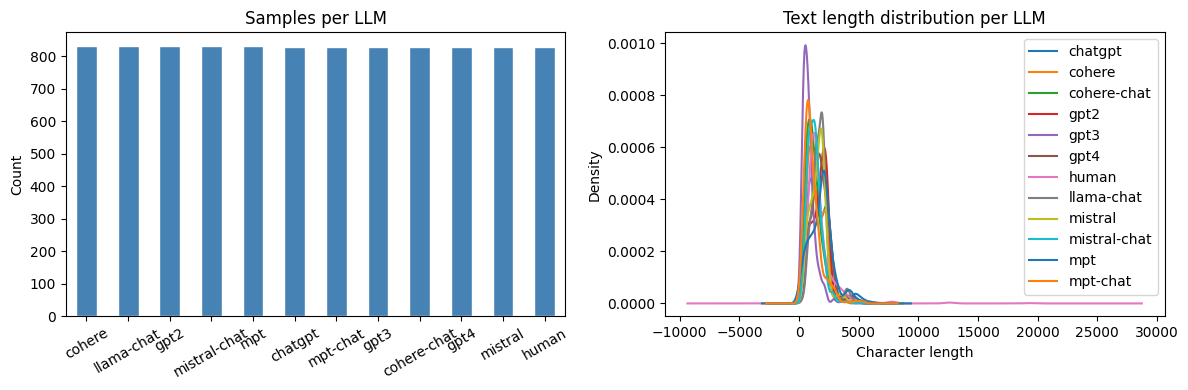

In [23]:
# ── Drop nulls
df = df[[TEXT_COL, LABEL_COL, 'split_source']].dropna().reset_index(drop=True)
print(f"Rows after dropping nulls: {len(df)}")

# ── Class distribution
counts = df[LABEL_COL].value_counts()
print("\nClass distribution:")
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — class counts
counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Samples per LLM")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Text length distribution
df["text_len"] = df[TEXT_COL].str.len()
df.groupby(LABEL_COL)["text_len"].plot(kind="kde", ax=axes[1], legend=True)
axes[1].set_title("Text length distribution per LLM")
axes[1].set_xlabel("Character length")

plt.tight_layout()
plt.show()

## Step 5 — Encode labels

Convert string class names → integer IDs so the model can use them.

In [24]:
le = LabelEncoder()
df["label"] = le.fit_transform(df[LABEL_COL])

NUM_CLASSES = len(le.classes_)
print(f"Classes ({NUM_CLASSES}): {list(le.classes_)}")
print(f"Mapping: { {c: i for i, c in enumerate(le.classes_)} }")

Classes (12): ['chatgpt', 'cohere', 'cohere-chat', 'gpt2', 'gpt3', 'gpt4', 'human', 'llama-chat', 'mistral', 'mistral-chat', 'mpt', 'mpt-chat']
Mapping: {'chatgpt': 0, 'cohere': 1, 'cohere-chat': 2, 'gpt2': 3, 'gpt3': 4, 'gpt4': 5, 'human': 6, 'llama-chat': 7, 'mistral': 8, 'mistral-chat': 9, 'mpt': 10, 'mpt-chat': 11}


## Step 6 — Train / validation / test split

- **Train** (70%) — model learns from this  
- **Validation** (15%) — tune hyperparameters, early stopping  
- **Test** (15%) — final unbiased evaluation  

`stratify` ensures every split has the same class proportions.

In [25]:
#train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
#val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

train_df = df[df['split_source'] == 'train'].copy()
val_df = df[df['split_source'] == 'val'].copy()
test_df = df[df['split_source'] == 'test'].copy()

train_df.drop(columns=['split_source'], inplace=True)
val_df.drop(columns=['split_source'], inplace=True)
test_df.drop(columns=['split_source'], inplace=True)

print(f"Train: {len(train_df):>5} samples")
print(f"Val:   {len(val_df):>5} samples")
print(f"Test:  {len(test_df):>5} samples")

Train:  7968 samples
Val:     995 samples
Test:    995 samples


## Step 7 — Stylometric feature extraction

These capture *writing style* signals that pure embeddings might miss:
- **avg_word_len** — average word length
- **type_token_ratio** — vocabulary richness (unique words / total words)
- **avg_sentence_len** — sentence complexity
- **punctuation_rate** — punctuation density
- **flesch_score** — Flesch readability score
- **stopword_ratio** — how many filler words used

In [26]:
STOPWORDS = set([
    "the","a","an","is","are","was","were","be","been","being",
    "have","has","had","do","does","did","will","would","could","should",
    "may","might","shall","to","of","in","for","on","with","at","by",
    "from","up","about","into","through","during","before","after",
    "and","but","or","nor","so","yet","not","no","it","its","this","that"
])

def stylometric_features(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # --- existing 6 ---
    avg_word_len     = np.mean([len(w) for w in words]) if words else 0
    ttr              = len(set(words)) / (len(words) + 1e-8)
    avg_sent_len     = np.mean([len(s.split()) for s in sentences]) if sentences else 0
    punct_rate       = sum(1 for c in text if c in '.,!?;:') / (len(text) + 1e-8)
    flesch           = textstat.flesch_reading_ease(text)
    stopword_ratio   = sum(1 for w in words if w in STOPWORDS) / (len(words) + 1e-8)

    # --- new powerful features ---
    # Sentence length variance (LLMs differ in consistency)
    sent_lens        = [len(s.split()) for s in sentences]
    sent_len_std     = np.std(sent_lens) if sent_lens else 0

    # Bullet/list usage (GPT tends to bullet more)
    bullet_rate      = len(re.findall(r'^\s*[-•*]\s', text, re.MULTILINE)) / (len(sentences) + 1e-8)

    # Question rate
    question_rate    = text.count('?') / (len(sentences) + 1e-8)

    # Parentheses usage
    paren_rate       = text.count('(') / (len(words) + 1e-8)

    # Uppercase word ratio (acronyms, emphasis)
    upper_ratio      = sum(1 for w in re.findall(r'\b[A-Z]{2,}\b', text)) / (len(words) + 1e-8)

    # Unique bigrams / total bigrams
    bigrams          = list(zip(words, words[1:]))
    bigram_diversity = len(set(bigrams)) / (len(bigrams) + 1e-8)

    # Average syllables per word (complexity)
    syllable_score   = textstat.syllable_count(text) / (len(words) + 1e-8)

    # Gunning fog index
    fog              = textstat.gunning_fog(text)

    # Hedge word ratio ("perhaps", "might", "could", etc.)
    hedges = {'perhaps','maybe','might','could','possibly','likely','somewhat','generally','often'}
    hedge_ratio = sum(1 for w in words if w in hedges) / (len(words) + 1e-8)

    return np.array([
        avg_word_len, ttr, avg_sent_len, punct_rate, flesch, stopword_ratio,
        sent_len_std, bullet_rate, question_rate, paren_rate,
        upper_ratio, bigram_diversity, syllable_score, fog, hedge_ratio
    ], dtype=np.float32)

STYLO_DIM = 15  # must match feature count above

# Compute for all splits
def compute_stylo(texts):
    return np.stack([stylometric_features(t) for t in tqdm(texts, desc="Stylometric")])

train_stylo = compute_stylo(train_df[TEXT_COL].tolist())
val_stylo   = compute_stylo(val_df[TEXT_COL].tolist())
test_stylo  = compute_stylo(test_df[TEXT_COL].tolist())

# Normalize stylometric features (zero mean, unit variance)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_stylo = scaler.fit_transform(train_stylo).astype(np.float32)
val_stylo   = scaler.transform(val_stylo).astype(np.float32)
test_stylo  = scaler.transform(test_stylo).astype(np.float32)

print(f"Stylometric feature matrix shape: {train_stylo.shape}")

Stylometric:   0%|          | 0/7968 [00:00<?, ?it/s]

Stylometric:   0%|          | 0/995 [00:00<?, ?it/s]

Stylometric:   0%|          | 0/995 [00:00<?, ?it/s]

Stylometric feature matrix shape: (7968, 15)


## Step 8 — Tokenizer & PyTorch Dataset

The tokenizer converts raw text → token IDs that the transformer understands.

`LLMDataset` wraps your data so PyTorch's `DataLoader` can batch it efficiently.

In [27]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Loaded tokenizer: {MODEL_NAME}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

Loaded tokenizer: roberta-base
Vocabulary size: 50,265


In [28]:
class LLMDataset(Dataset):
    def __init__(self, texts, labels, stylo_feats, tokenizer, max_len):
        self.texts      = texts
        self.labels     = labels
        self.stylo      = stylo_feats
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length    = self.max_len,
            padding       = "max_length",
            truncation    = True,
            return_tensors= "pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "stylo":          torch.tensor(self.stylo[idx]),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

def make_loader(df_split, stylo_arr, shuffle=False):
    ds = LLMDataset(
        texts       = df_split[TEXT_COL].tolist(),
        labels      = df_split["label"].tolist(),
        stylo_feats = stylo_arr,
        tokenizer   = tokenizer,
        max_len     = MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

train_loader = make_loader(train_df, train_stylo, shuffle=True)
val_loader   = make_loader(val_df,   val_stylo)
test_loader  = make_loader(test_df,  test_stylo)
print("DataLoaders ready.")

DataLoaders ready.


## Step 9 — Model architecture

```
Text → DistilBERT → [CLS] embedding (768-d)
                                        ↘
                                     Concat (768 + 6 = 774-d)  → Dropout → Linear → Softmax
                                        ↗
Stylometric features (6-d) ────────────
```

The `[CLS]` token from DistilBERT captures semantic + stylistic patterns.  
Stylometric features add explicit authorship signals.  
Together they give the classifier richer information than either alone.

In [29]:
class LLMClassifier(nn.Module):
    def __init__(self, model_name, stylo_dim, num_classes, dropout=0.3):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        hidden_size    = self.encoder.config.hidden_size   # 768 for distilbert
        combined_size  = hidden_size + stylo_dim

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, stylo):
        out   = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls   = out.last_hidden_state[:, 0, :]   # [CLS] token → (batch, 768)
        x     = torch.cat([cls, stylo], dim=1)   # concat stylo  → (batch, 774)
        return self.classifier(x)                # logits         → (batch, num_classes)

model = LLMClassifier(MODEL_NAME, STYLO_DIM, NUM_CLASSES, DROPOUT).to(DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     124,849,420
Trainable params: 124,849,420


## Step 10 — Handle class imbalance with weighted loss

If some LLMs have many more samples than others, the model will bias toward them.
We compute a weight inversely proportional to class frequency and pass it to `CrossEntropyLoss`.

In [30]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight = "balanced",
    classes      = np.arange(NUM_CLASSES),
    y            = train_df["label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print("Class weights:", {le.classes_[i]: round(w, 3) for i, w in enumerate(class_weights)})

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Class weights: {'chatgpt': np.float64(1.0), 'cohere': np.float64(1.0), 'cohere-chat': np.float64(1.002), 'gpt2': np.float64(0.998), 'gpt3': np.float64(0.998), 'gpt4': np.float64(1.002), 'human': np.float64(1.0), 'llama-chat': np.float64(1.002), 'mistral': np.float64(1.0), 'mistral-chat': np.float64(0.998), 'mpt': np.float64(0.998), 'mpt-chat': np.float64(1.002)}


## Step 11 — Optimizer and learning rate scheduler

- **AdamW** — Adam with weight decay, standard for fine-tuning transformers  
- **Linear warmup** — slowly increases LR for the first 10% of steps, then linearly decays.
  This prevents the pretrained weights from being destroyed early in training.

In [31]:
encoder_params    = list(model.encoder.parameters())
classifier_params = list(model.classifier.parameters())

optimizer = AdamW([
    {"params": encoder_params,    "lr": 1e-5},   # lower LR for pretrained layers
    {"params": classifier_params, "lr": 3e-4}    # higher LR for new classifier head
], weight_decay=0.01)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps    = warmup_steps,
    num_training_steps  = total_steps
)
print(f"Total training steps: {total_steps}  |  Warmup steps: {warmup_steps}")

Total training steps: 498  |  Warmup steps: 49


## Step 12 — Training loop

Each epoch:
1. **Train** — forward pass → loss → backprop → weight update  
2. **Validate** — evaluate on val set, no gradient computation  
3. **Checkpoint** — save model if validation loss improved  

`gradient clipping` prevents exploding gradients (common when fine-tuning).

In [32]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc="Train" if training else "Val", leave=False):
            input_ids  = batch["input_ids"].to(DEVICE)
            attn_mask  = batch["attention_mask"].to(DEVICE)
            stylo      = batch["stylo"].to(DEVICE)
            labels     = batch["label"].to(DEVICE)

            logits = model(input_ids, attn_mask, stylo)
            loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    flag = ""
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), CHECKPOINT)
        flag = "  ← saved"

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.3f}  |  "
          f"Val loss: {vl_loss:.4f}  acc: {vl_acc:.3f}{flag}")

print("\nTraining complete. Best checkpoint:", CHECKPOINT)

Train:   0%|          | 0/498 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/1  Train loss: 2.2368  acc: 0.229  |  Val loss: 1.9336  acc: 0.371  ← saved

Training complete. Best checkpoint: best_model.pt


## Step 13 — Plot training curves

If val loss starts rising while train loss keeps falling → overfitting. Use the saved checkpoint, not the final epoch.

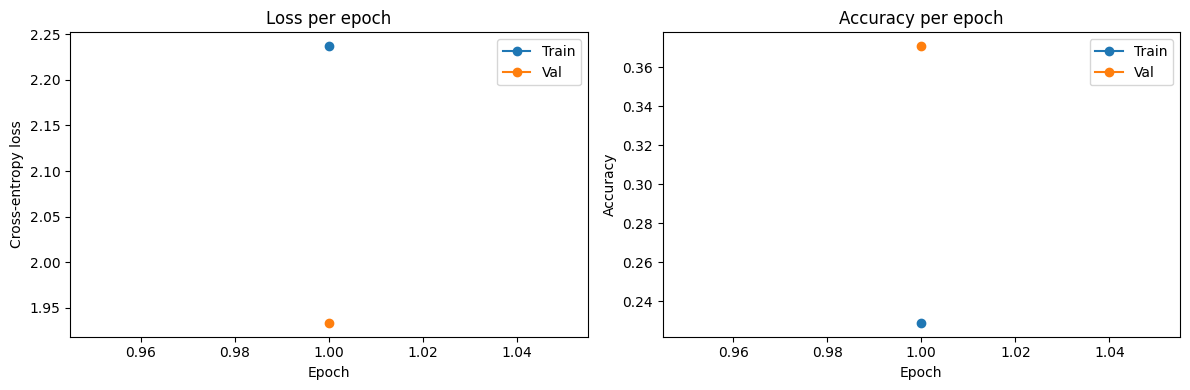

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   marker="o")
axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train", marker="o")
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   marker="o")
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 14 — Evaluate on the test set

Load the best checkpoint and run inference on the held-out test set.

In [34]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        stylo     = batch["stylo"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        logits = model(input_ids, attn_mask, stylo)
        preds  = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

print(f"Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Macro F1:      {f1_score(all_labels, all_preds, average='macro'):.4f}")
print()
print("Per-class report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Testing:   0%|          | 0/63 [00:00<?, ?it/s]

Test Accuracy: 0.3709
Macro F1:      0.3560

Per-class report:
              precision    recall  f1-score   support

     chatgpt       0.18      0.07      0.10        83
      cohere       0.67      0.24      0.35        84
 cohere-chat       0.25      0.16      0.19        83
        gpt2       0.47      0.17      0.25        83
        gpt3       0.58      0.88      0.70        82
        gpt4       0.33      0.47      0.38        83
       human       0.46      0.55      0.50        82
  llama-chat       0.24      0.45      0.31        84
     mistral       0.57      0.34      0.43        82
mistral-chat       0.32      0.23      0.27        83
         mpt       0.53      0.48      0.51        83
    mpt-chat       0.21      0.42      0.28        83

    accuracy                           0.37       995
   macro avg       0.40      0.37      0.36       995
weighted avg       0.40      0.37      0.36       995



## Step 15 — Confusion matrix

Shows which models get misclassified as which. Off-diagonal cells = errors.

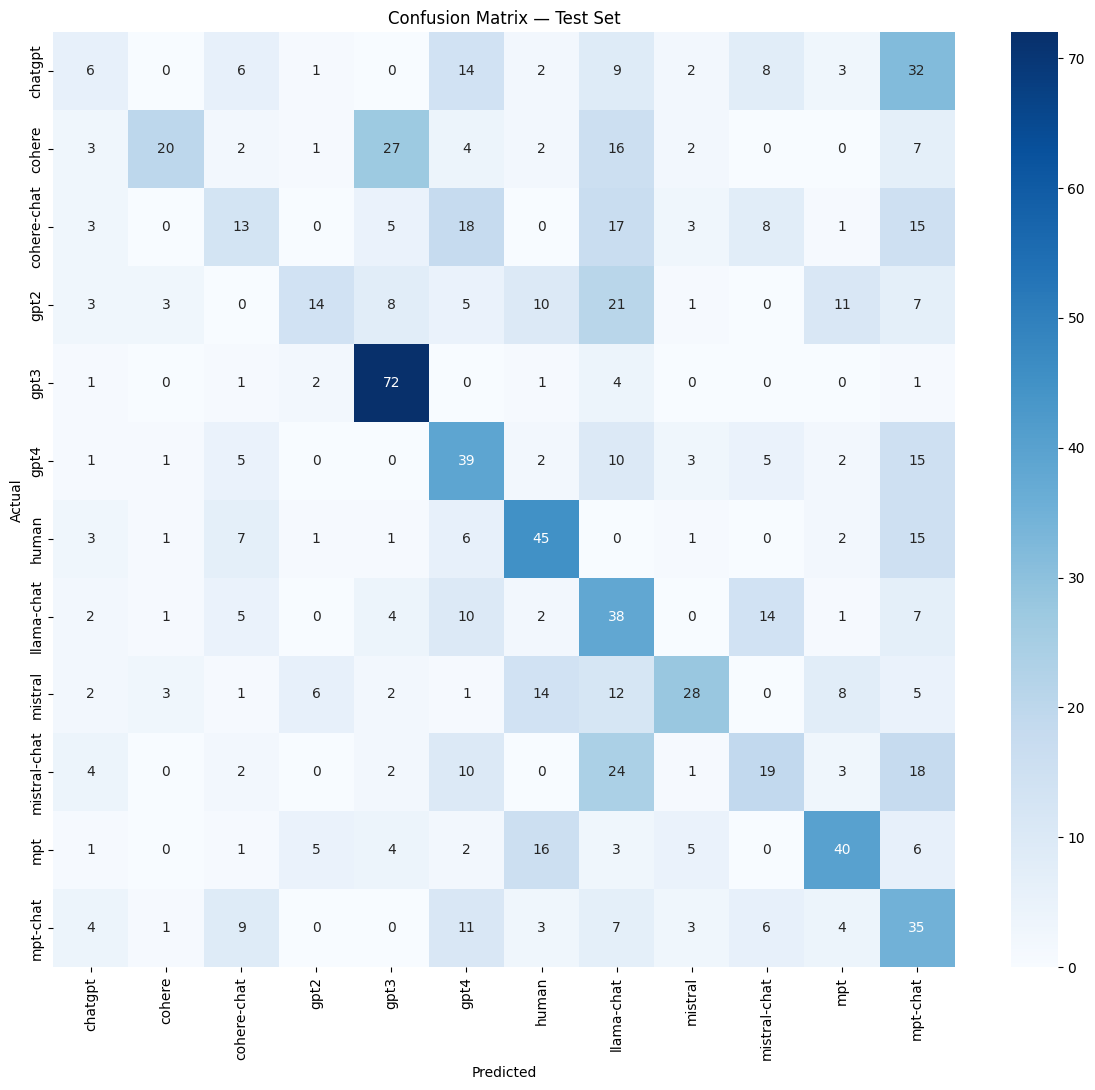

In [35]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(max(6, NUM_CLASSES), max(5, NUM_CLASSES - 1)))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = "d",
    cmap        = "Blues",
    xticklabels = le.classes_,
    yticklabels = le.classes_
)
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Step 16 — Predict on a new text

Use this function to classify any new text sample.

In [36]:
def predict(text: str) -> dict:
    model.eval()
    enc = tokenizer(
        text,
        max_length    = MAX_LEN,
        padding       = "max_length",
        truncation    = True,
        return_tensors= "pt"
    )
    stylo_feat = torch.tensor(
        scaler.transform([stylometric_features(text)]),
        dtype=torch.float
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(
            enc["input_ids"].to(DEVICE),
            enc["attention_mask"].to(DEVICE),
            stylo_feat
        )
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_class = le.classes_[np.argmax(probs)]
    return {
        "prediction":   pred_class,
        "confidence":   f"{max(probs)*100:.1f}%",
        "all_probs":    {c: f"{p*100:.1f}%" for c, p in zip(le.classes_, probs)}
    }

# ── Try it out
sample_text = "Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. Hi my name is Ayush Yadav I am a Human, Lets see if the machine is able to correctly predict me as a human or it classifies me as any llm. "
result      = predict(sample_text)
print(f"Predicted LLM : {result['prediction']}")
print(f"Confidence    : {result['confidence']}")
print(f"All probabilities: {result['all_probs']}")

Predicted LLM : human
Confidence    : 23.5%
All probabilities: {'chatgpt': '4.5%', 'cohere': '4.0%', 'cohere-chat': '2.4%', 'gpt2': '15.2%', 'gpt3': '2.4%', 'gpt4': '2.3%', 'human': '23.5%', 'llama-chat': '2.9%', 'mistral': '12.2%', 'mistral-chat': '2.4%', 'mpt': '23.1%', 'mpt-chat': '5.1%'}


## Step 17 — Explainability with SHAP

SHAP shows which input features pushed the prediction toward each class.
Here we explain the stylometric features (SHAP works best on tabular inputs).

Stylometric:   0%|          | 0/50 [00:00<?, ?it/s]

Stylometric:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

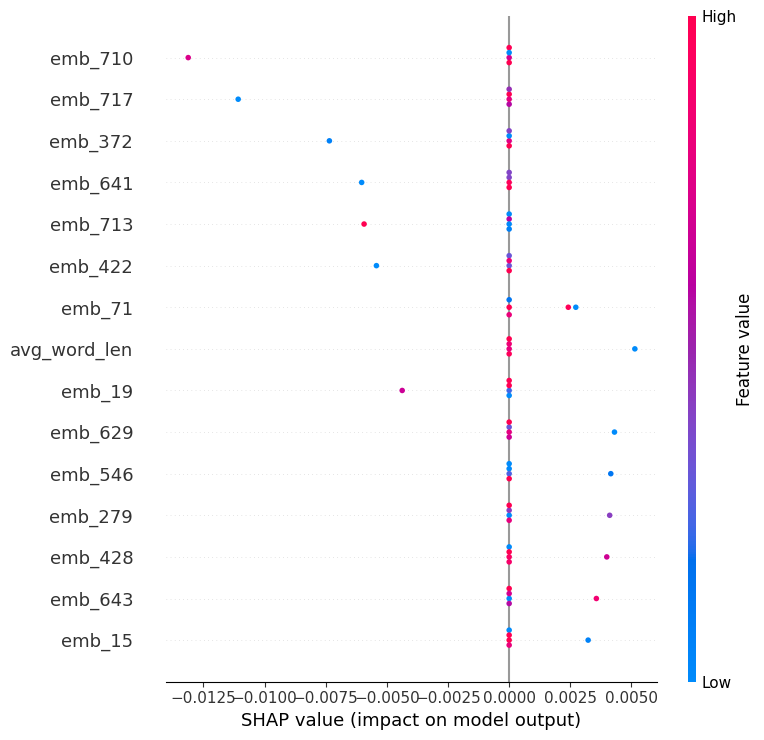

In [37]:
import shap

# Extract embeddings from frozen encoder, then explain the classifier head
def get_combined_features(texts, stylo_arr):
    all_feats = []
    model.eval()
    ds = LLMDataset(texts, [0]*len(texts), stylo_arr, tokenizer, MAX_LEN)
    dl = DataLoader(ds, batch_size=BATCH_SIZE)
    with torch.no_grad():
        for batch in dl:
            ids   = batch["input_ids"].to(DEVICE)
            mask  = batch["attention_mask"].to(DEVICE)
            stylo = batch["stylo"].to(DEVICE)
            cls   = model.encoder(input_ids=ids, attention_mask=mask).last_hidden_state[:, 0, :]
            feats = torch.cat([cls, stylo], dim=1).cpu().numpy()
            all_feats.append(feats)
    return np.vstack(all_feats)

# Use a small background sample for SHAP (keeps it fast)
bg_texts  = train_df[TEXT_COL].sample(50, random_state=SEED).tolist()
bg_stylo  = scaler.transform(compute_stylo(bg_texts))
bg_feats  = get_combined_features(bg_texts, bg_stylo)

ex_texts  = test_df[TEXT_COL].sample(20, random_state=SEED).tolist()
ex_stylo  = scaler.transform(compute_stylo(ex_texts))
ex_feats  = get_combined_features(ex_texts, ex_stylo)

# Wrap classifier head for SHAP
def clf_head(x):
    t = torch.tensor(x, dtype=torch.float).to(DEVICE)
    with torch.no_grad():
        logits = model.classifier(t)
        return torch.softmax(logits, dim=1).cpu().numpy()

explainer   = shap.KernelExplainer(clf_head, shap.sample(bg_feats, 30))
shap_values = explainer.shap_values(ex_feats[:5], nsamples=100)

# Plot for first class
feature_names = [f"emb_{i}" for i in range(768)] + ["avg_word_len","type_token_ratio","avg_sent_len","punct_rate","flesch","stopword_ratio"]
# Use [:, :, 0] to select all samples, all features, for class index 0
shap.summary_plot(shap_values[:, :, 0], ex_feats[:5], feature_names=feature_names, max_display=15, show=True)

## Step 18 — Save everything for reuse

In [38]:
import pickle

# Save label encoder and scaler
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Model is already saved as best_model.pt via training loop

print("Saved:")
print("  best_model.pt     — model weights (load with torch.load)")
print("  label_encoder.pkl — LabelEncoder (maps int → LLM name)")
print("  scaler.pkl        — StandardScaler for stylometric features")

Saved:
  best_model.pt     — model weights (load with torch.load)
  label_encoder.pkl — LabelEncoder (maps int → LLM name)
  scaler.pkl        — StandardScaler for stylometric features


In [39]:
!zip -r my_archive.zip /kaggle/working/.virtual_documents/


  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 67%)


In [41]:
# import pickle, torch
# le2     = pickle.load(open("label_encoder.pkl", "rb"))
# scaler2 = pickle.load(open("scaler.pkl", "rb"))
# model2  = LLMClassifier(MODEL_NAME, STYLO_DIM, NUM_CLASSES, DROPOUT)
# model2.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
# model2.to(DEVICE)
# model2.eval()
print("Reload snippet above — uncomment and run to restore the full pipeline.")

Reload snippet above — uncomment and run to restore the full pipeline.
